# Scenario 1: Central to Strathfield (round-trip schedule)

**43008 Reinforcement Learning, Assignment 3 (RailTech).**

The scenario is a **prebuilt Flatland environment** (rail + fleet + timetable)
built by `scripts/build_scenario1_env.py` and loaded from `data/`. It is the
Central to Strathfield (Main Suburban) corridor as a 92x37 turnback grid run on
the real round-trip schedule. The notebook adds the observation, the env
factory, the wrappers and the evaluation, with no `src/` imports.

- **Environment:** [Flatland](https://flatland.aicrowd.com/intro.html), the
  Central to Strathfield (Main Suburban) corridor.
- **Fleet:** real TfNSW services (T1, T2, T3, T9, CCN, BMT) as physical round
  trips (out to Central, turn back, return to Strathfield).
- **Data:** `data/levels/central_strathfield.pkl` (prebuilt env) and
  `data/schedules/central_strathfield_roundtrips.json` (source schedule). Build
  the env with `python scripts/build_scenario1_env.py`, then run the notebook
  from the repo root.
- **Algorithms:** PPO (primary), A2C, DQN, one shared policy across agents.
- **GUI:** Flatland's built-in renderer (headless PILSVG for figures), which the
  assignment permits in place of a separate interface.


## 1. Setup

Installs the Flatland / Stable-Baselines3 stack when missing (Colab), then
imports everything the notebook needs. Environment code lives in the sections
below; the level and schedule are read from `data/`.


In [1]:
import importlib.util
import subprocess
import sys

# Colab has none of this by default; install once if Flatland is absent.
if importlib.util.find_spec("flatland") is None:
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         "flatland-rl", "stable-baselines3", "supersuit", "pettingzoo"],
        check=True,
    )

import io
import json
import math
import os
import tempfile
from dataclasses import dataclass
from pathlib import Path
from typing import Any, Callable, Optional, Sequence

import numpy as np
import pandas as pd
import matplotlib

try:
    get_ipython  # inside IPython / Jupyter: keep its inline backend
except NameError:
    matplotlib.use("Agg")  # headless: plt.show() must not open a GUI window

import matplotlib.pyplot as plt

import gymnasium as gym
from flatland.core.grid.grid4 import Grid4TransitionsEnum
from flatland.core.effects_generator import (
    find_effects_generator,
    make_multi_effects_generator,
)
from flatland.envs.malfunction_effects_generators import MalfunctionEffectsGenerator
from flatland.envs.malfunction_generators import (
    MalfunctionParameters,
    ParamMalfunctionGen,
)
from flatland.envs.observations import TreeObsForRailEnv
from flatland.envs.persistence import RailEnvPersister
from flatland.envs.predictions import ShortestPathPredictorForRailEnv
from flatland.envs.record_steps_effects_generator import RecordStepsEffectsGenerator
from flatland.envs.rail_env import RailEnv
from flatland.envs.rail_generators import rail_from_file
from flatland.envs.rail_trainrun_data_structures import Waypoint
from flatland.envs.rewards import DefaultRewards
from flatland.envs.step_utils.states import TrainState
from flatland.envs.timetable_utils import Line, Timetable
from flatland.ml.pettingzoo.wrappers import PettingzooFlatland

SCENARIO = "central-strathfield"   # or "granville-harris-park"
CONDITION = "normal"               # or "delayed" (Poisson malfunctions)
FORCE_STOP = True                  # env-enforce scheduled stops (see §2.4)
SEED = 0
SEEDS = [0, 1, 2]               # seeds for mean ± std evaluation
MAX_DEPTH = 3                      # tree depth (Flatland baseline uses 3)
PREDICTOR_DEPTH = 50               # shortest-path predictor depth (baseline)
def _find_root(start=None):
    """Repo root (for docs/results paths) whether run from repo root or notebooks/."""
    p = (start or Path.cwd()).resolve()
    for cand in [p, *p.parents]:
        if (cand / ".git").exists() or (cand / "data").exists():
            return cand
    return p


ROOT = _find_root()
DATA = ROOT / "data"
DOCS = ROOT / "docs" / "comparison"
GREEDY_BASELINE = {}

print("setup complete")

setup complete


## 2. Scenario 1 environment

Everything needed to build the environment lives here: the level loader, the
schedule conversion, the tree observation, the env factory and the greedy
baseline.


### 2.1 Prebuilt scenario env

`ScenarioSpec` points at a prebuilt Flatland env (`.pkl`) plus the source
schedule JSON. `scripts/build_scenario1_env.py` reads the rail grid and the
round-trip schedule, turns each round trip into agents and saves the whole env,
so `load_level` is a one-line `RailEnvPersister.load_new`. The level is previewed
in §3.1.


In [2]:
@dataclass(frozen=True)
class ScenarioSpec:
    """One scenario: a prebuilt Flatland env plus its source schedule file.

    The env (rail + agents + line + timetable) is built by
    ``scripts/build_scenario1_env.py`` and saved to ``level_path``. The notebook
    only loads it; ``schedule_path`` is used to display the timetable in §3.
    """

    name: str
    level_path: Path
    schedule_path: Path


def load_level(spec: ScenarioSpec, obs_builder=None, rewards=None):
    """Load ``spec``'s prebuilt Flatland env.

    Station cells, the fleet and the timetable all come from the saved env, so
    nothing is rebuilt here. Run the notebook from the repo root and build the
    env first with ``python scripts/build_scenario1_env.py``.
    """
    if not spec.level_path.exists():
        raise FileNotFoundError(
            f"{spec.name}: env not found at {spec.level_path}. "
            "Run scripts/build_scenario1_env.py, then run the notebook from the repo root."
        )
    env, env_dict = RailEnvPersister.load_new(
        str(spec.level_path), obs_builder=obs_builder, rewards=rewards
    )
    env.seed_history = list(env.seed_history) or [0]
    return env, env_dict


def show_image(array):
    """Display a numpy RGB image inline, falling back to a temp PNG."""
    from PIL import Image

    try:
        from IPython.display import Image as IPyImage, display

        buf = io.BytesIO()
        Image.fromarray(array).save(buf, format="PNG")
        display(IPyImage(data=buf.getvalue()))
    except Exception:
        out = Path(tempfile.gettempdir()) / "scenario1_level.png"
        Image.fromarray(array).save(out)
        print("saved:", out)


### 2.2 Tree observation

Gym-compatible flattened / normalized tree observation, a ray-free
re-implementation of Flatland's RLlib-flavoured builder (keeps the dependency
set to Flatland + SB3). Adapted from the Mava project (Apache-2.0).

In [3]:
class GymTreeObsForRailEnv(TreeObsForRailEnv):
    """Flattened, normalized tree observation with a gym observation space.

    The same flattened normalized tree as Flatland's
    ``FlattenedNormalizedTreeObsForRailEnv``, but without its RLlib (ray)
    dependency, so the notebook only needs Flatland and SB3. The tree is split
    into three feature groups (data, distance, agent data), each traversed
    depth-first in pre-order, concatenated and normalized to [-1, 1].
    """

    NUM_FEATURES = 12
    NUM_BRANCHES = 4
    NUM_DATA_FEATURE_GROUP = 6
    NUM_DISTANCE_FEATURE_GROUP = 1
    NUM_AGENT_DATA_FEATURE_GROUP = 5

    def __init__(self, observation_radius: int = 2, **kwargs):
        super().__init__(**kwargs)
        self.observation_radius = observation_radius
        self._len_data = self._len(self.max_depth, self.NUM_DATA_FEATURE_GROUP)
        self._len_distance = self._len(self.max_depth, self.NUM_DISTANCE_FEATURE_GROUP)
        self._len_agent_data = self._len(self.max_depth, self.NUM_AGENT_DATA_FEATURE_GROUP)

    @classmethod
    def _len(cls, tree_depth: int, num_features: int) -> int:
        k = num_features
        for _ in range(tree_depth):
            k = k * cls.NUM_BRANCHES + num_features
        return k

    @staticmethod
    def _split_node_into_feature_groups(node):
        data = np.zeros(6)
        distance = np.zeros(1)
        agent_data = np.zeros(5)

        data[0] = node.dist_own_target_encountered
        data[1] = node.dist_other_target_encountered
        data[2] = node.dist_other_agent_encountered
        data[3] = node.dist_potential_conflict
        data[4] = node.dist_unusable_switch
        data[5] = node.dist_to_next_branch

        distance[0] = node.dist_min_to_target

        agent_data[0] = node.num_agents_same_direction
        agent_data[1] = node.num_agents_opposite_direction
        agent_data[2] = node.num_agents_malfunctioning
        agent_data[3] = node.speed_min_fractional
        agent_data[4] = node.num_agents_ready_to_depart

        return data, distance, agent_data

    def _split_subtree_into_feature_groups(self, node, current_tree_depth, max_tree_depth):
        if node == -np.inf:
            remaining_depth = max_tree_depth - current_tree_depth
            num_remaining_nodes = int((4 ** (remaining_depth + 1) - 1) / (4 - 1))
            return (
                [-np.inf] * num_remaining_nodes * self.NUM_DATA_FEATURE_GROUP,
                [-np.inf] * num_remaining_nodes * self.NUM_DISTANCE_FEATURE_GROUP,
                [-np.inf] * num_remaining_nodes * self.NUM_AGENT_DATA_FEATURE_GROUP,
            )

        data, distance, agent_data = self._split_node_into_feature_groups(node)

        if not node.childs:
            return data, distance, agent_data

        for direction in self.tree_explored_actions_char:
            sub_data, sub_distance, sub_agent_data = self._split_subtree_into_feature_groups(
                node.childs[direction], current_tree_depth + 1, max_tree_depth
            )
            data = np.concatenate((data, sub_data))
            distance = np.concatenate((distance, sub_distance))
            agent_data = np.concatenate((agent_data, sub_agent_data))

        return data, distance, agent_data

    def split_tree_into_feature_groups(self, tree, max_tree_depth):
        data, distance, agent_data = self._split_node_into_feature_groups(tree)
        for direction in self.tree_explored_actions_char:
            sub_data, sub_distance, sub_agent_data = self._split_subtree_into_feature_groups(
                tree.childs[direction], 1, max_tree_depth
            )
            data = np.concatenate((data, sub_data))
            distance = np.concatenate((distance, sub_distance))
            agent_data = np.concatenate((agent_data, sub_agent_data))
        return data, distance, agent_data

    @staticmethod
    def _max_lt(seq, val):
        _max = 0
        idx = len(seq) - 1
        while idx >= 0:
            if seq[idx] < val and seq[idx] >= 0 and seq[idx] > _max:
                _max = seq[idx]
            idx -= 1
        return _max

    @staticmethod
    def _min_gt(seq, val):
        _min = np.inf
        idx = len(seq) - 1
        while idx >= 0:
            if seq[idx] >= val and seq[idx] < _min:
                _min = seq[idx]
            idx -= 1
        return _min

    def _norm_obs_clip(self, obs, clip_min=-1, clip_max=1, fixed_radius=0, normalize_to_range=False):
        if fixed_radius > 0:
            max_obs = fixed_radius
        else:
            max_obs = max(1, self._max_lt(obs, 1000)) + 1

        min_obs = 0
        if normalize_to_range:
            min_obs = self._min_gt(obs, 0)
        if min_obs > max_obs:
            min_obs = max_obs
        if max_obs == min_obs:
            return np.clip(np.array(obs) / max_obs, clip_min, clip_max)
        norm = np.abs(max_obs - min_obs)
        return np.clip((np.array(obs) - min_obs) / norm, clip_min, clip_max)

    def normalize_obs(self, obs: np.ndarray) -> np.ndarray:
        data = obs[: self._len_data]
        distance = obs[self._len_data : self._len_data + self._len_distance]
        agent_data = obs[-self._len_agent_data :]

        data = self._norm_obs_clip(data, fixed_radius=self.observation_radius)
        distance = self._norm_obs_clip(distance, normalize_to_range=True)
        agent_data = np.clip(agent_data, -1, 1)
        return np.concatenate((np.concatenate((data, distance)), agent_data))

    def get(self, handle: Optional[int] = 0) -> np.ndarray:
        observation = super().get(handle)
        data, distance, agent_data = self.split_tree_into_feature_groups(observation, self.max_depth)
        flattened = np.concatenate((np.concatenate((data, distance)), agent_data))
        return self.normalize_obs(flattened)

    def get_len_flattened(self) -> int:
        k = self.NUM_FEATURES
        for _ in range(self.max_depth):
            k = k * self.NUM_BRANCHES + self.NUM_FEATURES
        return k

    def get_observation_space(self, handle: int = 0) -> gym.Space:
        return gym.spaces.Box(low=-1.0, high=1.0, shape=(self.get_len_flattened(),), dtype=np.float64)


### 2.3 Scenario registry

`SCENARIOS` maps a scenario name to its `ScenarioSpec`. Scenario 1
(`central-strathfield`) loads `data/levels/central_strathfield.pkl` with the
schedule `data/schedules/central_strathfield_roundtrips.json`. Scenario 2 is a
TODO placeholder (§9).

This section also defines `CONDITIONS` (normal / delayed) and the schedule
loader used for the §3 display. The prebuilt env already carries the agents and
their per-stop timing (1 Flatland step = 20 real seconds; expresses run at
1 cell/step, all-stops at 0.5 cell/step).


In [4]:
# Scenario registry: scenario 1 is Central-Strathfield, a prebuilt env built by
# scripts/build_scenario1_env.py; scenario 2 is a TODO placeholder.
SCENARIOS: dict[str, ScenarioSpec | None] = {
    "central-strathfield": ScenarioSpec(
        name="central-strathfield",
        level_path=DATA / "levels" / "central_strathfield.pkl",
        schedule_path=DATA / "schedules" / "central_strathfield_roundtrips.json",
    ),
    "granville-harris-park": None,  # TODO(§9)
}

# Operating conditions: "normal" is deterministic, "delayed" injects Poisson
# malfunctions (the paper's 1/540 interval).
CONDITIONS: dict[str, float | None] = {
    "normal": None,
    "delayed": 1 / 540,
}


def get_scenario(name: str = SCENARIO) -> ScenarioSpec:
    spec = SCENARIOS.get(name)
    if spec is None:
        raise NotImplementedError(f"Scenario {name!r} is not implemented (see §9)")
    return spec


def load_timetable(scenario: str = SCENARIO) -> list[dict]:
    """Return a scenario's raw service list (used to display the schedule in §3)."""
    spec = get_scenario(scenario)
    if not spec.schedule_path.exists():
        raise FileNotFoundError(
            f"{spec.name}: schedule not found at {spec.schedule_path}. "
            "Run the notebook from the repo root so data/schedules/ is visible."
        )
    return json.loads(spec.schedule_path.read_text())["services"]


### 2.4 Environment factory

`make_env(scenario, condition)` combines a level with its schedule;
`make_parallel_env()` wraps it for PettingZoo / SuperSuit and, by default,
installs the env-enforced stop reflex (`FORCE_STOP` in §1). Scenarios come from
the `SCENARIOS` registry (§2.3) and operating conditions (normal / delayed) from
`CONDITIONS`.


In [5]:
def silence_tree_walk_warnings() -> None:
    """Suppress Flatland's benign tree-search diagnostic on this grid.

    The corridor ends are plain straight cells rather than dead-ends, so the
    tree observation's forward walk steps one cell past the track and prints
    ``WRONG CELL TYPE detected in tree-search`` every step. We shadow the
    builtin ``print`` used *inside the observations module only*. Idempotent.
    """
    import builtins

    import flatland.envs.observations as observations

    if getattr(observations, "_scenario1_print_patched", False):
        return
    original_print = builtins.print

    def _filtered_print(*args, **kwargs):
        if args and isinstance(args[0], str) and args[0].startswith(
            "WRONG CELL TYPE detected in tree-search"
        ):
            return
        original_print(*args, **kwargs)

    observations.print = _filtered_print
    observations._scenario1_print_patched = True


def make_env(
    scenario: str = SCENARIO,
    condition: str = CONDITION,
    seed: int | None = None,
    max_depth: int = MAX_DEPTH,
    predictor_depth: int = PREDICTOR_DEPTH,
    collision_factor: float = 0.0,
    not_served_penalty: float = 1.0,
    malfunction_rate: float | None = None,
    malfunction_duration: tuple[int, int] = (20, 50),
) -> RailEnv:
    """Build a reset RailEnv for one scenario and operating condition.

    Loads the prebuilt env (built by ``scripts/build_scenario1_env.py``), installs
    the tree observation and rewards, injects the operating condition's
    malfunctions and resets. ``condition`` selects the disruption level from
    :data:`CONDITIONS`; pass ``malfunction_rate`` to override it directly.
    """
    silence_tree_walk_warnings()
    spec = get_scenario(scenario)

    obs_builder = GymTreeObsForRailEnv(
        max_depth=max_depth,
        predictor=ShortestPathPredictorForRailEnv(max_depth=predictor_depth),
    )
    rewards = DefaultRewards(
        collision_factor=collision_factor,
        intermediate_not_served_penalty=not_served_penalty,
    )
    env, _ = load_level(spec, obs_builder=obs_builder, rewards=rewards)

    rate = CONDITIONS[condition] if malfunction_rate is None else malfunction_rate
    if rate is not None:
        malfunction = MalfunctionEffectsGenerator(
            ParamMalfunctionGen(
                MalfunctionParameters(
                    malfunction_rate=rate,
                    min_duration=malfunction_duration[0],
                    max_duration=malfunction_duration[1],
                )
            )
        )
        # A loaded env injects malfunctions through its effects_generator, so
        # rebuild it, keeping step recording if present.
        record_steps = find_effects_generator(env.effects_generator, RecordStepsEffectsGenerator)
        env.effects_generator = (
            make_multi_effects_generator(malfunction, record_steps)
            if record_steps is not None else malfunction
        )

    env.reset(random_seed=seed)
    return env


def force_stop_actions(
    env: RailEnv, actions: dict[int, int], served: dict[int, set], dwell_extra: int = 0
) -> dict[int, int]:
    """Force a train to STOP at each scheduled intermediate stop and hold its dwell.

    Any agent standing on a halting cell of its next unserved intermediate stop is
    overridden to ``STOP_MOVING`` so the stop counts as served (Flatland only
    credits a stop when the train is ``STOPPED`` there). It is held until it is
    ``STOPPED`` *and* the scheduled earliest departure (plus ``dwell_extra`` steps,
    to absorb braking/acceleration) is reached, then control returns to the policy.
    """
    from flatland.envs.rail_env_action import RailEnvActions as A

    out = dict(actions)
    for handle in list(out.keys()):
        agent = env.agents[handle]
        cfg = agent.current_configuration
        if cfg is None or cfg[0] is None:
            continue
        pos = tuple(int(x) for x in cfg[0])
        waypoints = agent.waypoints
        if waypoints is None:
            continue
        for j in range(1, len(waypoints) - 1):
            alts = {
                (tuple(int(x) for x in wp.position), int(wp.direction))
                for wp in waypoints[j]
                if wp.direction is not None
            }
            if (pos, int(cfg[1])) not in alts:
                continue
            earliest = agent.waypoints_earliest_departure[j]
            if agent.state == TrainState.STOPPED:
                served.setdefault(handle, set()).add(j)
                if earliest is not None and env._elapsed_steps < earliest + dwell_extra:
                    out[handle] = A.STOP_MOVING.value  # hold for the scheduled dwell
            else:
                out[handle] = A.STOP_MOVING.value      # force stop on arrival
            break
    return out


def install_force_stop(parallel_env, dwell_extra: int = 0):
    """Wrap a PettingZoo parallel env so scheduled stops are env-enforced."""
    raw = parallel_env._wrap
    served = {h: set() for h in raw.get_agent_handles()}

    original_reset = parallel_env.reset

    def reset(*args, **kwargs):
        result = original_reset(*args, **kwargs)
        served.clear()
        served.update({h: set() for h in raw.get_agent_handles()})
        return result

    parallel_env.reset = reset

    original_step = parallel_env.step

    def step(actions):
        return original_step(force_stop_actions(raw, actions, served, dwell_extra))

    parallel_env.step = step
    return parallel_env


def make_parallel_env(
    scenario: str = SCENARIO,
    condition: str = CONDITION,
    seed: int | None = None,
    force_stop: bool = FORCE_STOP,
    dwell_extra: int = 0,
    **overrides: Any,
):
    """PettingZoo parallel env for one scenario/condition (SB3-compatible).

    ``force_stop`` (default :data:`FORCE_STOP`) env-enforces scheduled stops: a
    train at a stop cell is held for the scheduled dwell (see
    :func:`force_stop_actions`). Pass ``force_stop=False`` to leave stopping to the
    policy (it then has to choose ``STOP_MOVING`` itself).
    """
    env = PettingzooFlatland(
        make_env(scenario=scenario, condition=condition, seed=seed, **overrides)
    ).parallel_env()
    return install_force_stop(env, dwell_extra) if force_stop else env


### 2.5 Greedy baseline and rollout GIF

`greedy_actions()` follows the distance map to each agent's target; it is the
reference policy for the comparison and the default for `rollout_gif()`.


In [6]:
def greedy_actions(env: RailEnv) -> dict[int, int]:
    """Distance-map greedy baseline that also serves intermediate stops.

    Each agent routes to its final target via the distance map. Targets and
    intermediate waypoints are matched on the full ``(position, direction)``
    configuration (a ``None`` waypoint direction is treated as any heading), so
    the baseline is direction-aware, which matters on a round trip where the
    origin and terminus share a position. At an intermediate waypoint it stops
    (``STOP_MOVING``) so the stop counts as served (Flatland requires
    ``TrainState.STOPPED`` at the waypoint), then departs once its scheduled
    earliest departure is due.
    """
    from flatland.envs.rail_env_action import RailEnvActions as A

    distance_map = env.distance_map.get()
    step = env._elapsed_steps
    actions: dict[int, int] = {}
    for handle in env.get_agent_handles():
        agent = env.agents[handle]
        configuration = agent.current_configuration
        if configuration is None or configuration[0] is None:
            # Off-map (WAITING / READY_TO_DEPART): a movement action triggers
            # departure once the earliest departure is reached.
            actions[handle] = A.MOVE_FORWARD.value
            continue
        position = tuple(int(x) for x in configuration[0])
        direction = int(configuration[1])

        if any(
            tuple(int(x) for x in target[0]) == position
            and (target[1] is None or int(target[1]) == direction)
            for target in agent.targets
        ):
            actions[handle] = A.STOP_MOVING.value
            continue

        # Intermediate stop: dwell (STOPPED) to serve it, leave on schedule.
        at_intermediate = False
        for j in range(1, len(agent.waypoints) - 1):
            if any(
                tuple(int(x) for x in wp.position) == position
                and (wp.direction is None or int(wp.direction) == direction)
                for wp in agent.waypoints[j]
            ):
                at_intermediate = True
                earliest = agent.waypoints_earliest_departure[j]
                if agent.state == TrainState.STOPPED and (earliest is None or step >= earliest):
                    actions[handle] = A.MOVE_FORWARD.value
                else:
                    actions[handle] = A.STOP_MOVING.value
                break
        if at_intermediate:
            continue

        best: tuple[float, int] | None = None
        for next_position, next_direction in env.rail.get_successor_configurations(
            (position, direction)
        ):
            row, col = int(next_position[0]), int(next_position[1])
            value = distance_map[handle, row, col, int(next_direction)]
            if not np.isfinite(value):
                continue
            delta = (int(next_direction) - direction) % 4
            if delta == 2:  # reversal not allowed
                continue
            if best is None or value < best[0]:
                best = (value, delta)

        if best is None or best[1] == 0:
            actions[handle] = A.MOVE_FORWARD.value
        elif best[1] == 1:
            actions[handle] = A.MOVE_RIGHT.value
        else:
            actions[handle] = A.MOVE_LEFT.value
    return actions


def rollout_gif(
    env: RailEnv,
    out_path: str | Path,
    policy: Callable[[RailEnv], dict[int, int]] | None = None,
    max_steps: int | None = None,
    fps: int = 10,
    screen_width: int = 1000,
    seed: int | None = None,
    force_stop: bool = FORCE_STOP,
    dwell_extra: int = 0,
) -> dict[str, Any]:
    """Run one episode and save an animated GIF (default policy: greedy).

    Returns a small stats dict (steps, score, completion, mean delay) so the
    baseline can be compared against trained algorithms.
    """
    from PIL import Image
    from flatland.utils.rendertools import RenderTool

    if max_steps is None:
        max_steps = env._max_episode_steps
    screen_height = max(200, int(screen_width * env.height / max(env.width, 1)))

    env.reset(random_seed=seed)
    served = {h: set() for h in env.get_agent_handles()}
    renderer = RenderTool(env, gl="PILSVG", screen_width=screen_width, screen_height=screen_height)
    handles = env.get_agent_handles()
    num_agents = env.get_num_agents()
    cumulative = {h: 0.0 for h in handles}
    reached = {h: False for h in handles}
    done_step: dict[int, int] = {}
    frames: list = []

    def grab() -> None:
        frames.append(
            Image.fromarray(
                renderer.render_env(
                    show=False, show_agents=True, show_observations=False, return_image=True
                )
            )
        )

    grab()
    steps = 0
    for step in range(1, max_steps + 1):
        actions = policy(env) if policy is not None else greedy_actions(env)
        if force_stop:
            actions = force_stop_actions(env, actions, served, dwell_extra)
        _, rewards, terminations, _ = env.step(actions)
        for handle, reward in rewards.items():
            if reward is not None:
                cumulative[handle] += float(reward)
        for handle in handles:
            if env.agents[handle].state == TrainState.DONE:
                reached[handle] = True
                done_step.setdefault(handle, step)
        grab()
        steps = step
        if terminations.get("__all__"):
            break

    renderer.close_window()
    out_path = Path(out_path)
    out_path.parent.mkdir(parents=True, exist_ok=True)
    frames[0].save(
        out_path,
        save_all=True,
        append_images=frames[1:],
        duration=int(1000 / max(fps, 1)),
        loop=0,
    )

    rewards_arr = np.array([cumulative[h] for h in handles])
    score = float(
        env.rewards.normalize(
            *rewards_arr, num_agents=num_agents, max_episode_steps=env._max_episode_steps
        )
    ) - 1.0
    delays = [
        done_step[h] - env.agents[h].waypoints_latest_arrival[-1]
        for h in handles
        if h in done_step and env.agents[h].waypoints_latest_arrival[-1] is not None
    ]
    return {
        "gif": str(out_path),
        "frames": len(frames),
        "steps": steps,
        "score": score,
        "completion": sum(reached.values()) / max(num_agents, 1),
        "mean_delay_steps": float(np.mean(delays)) if delays else None,
        "on_time": float(np.mean([d <= 0 for d in delays])) if delays else None,
    }

### 2.6 Scenario data and build

The rail grid, the round-trip schedule and the assembled env live outside the
notebook, so it stays small and readable. `scripts/build_scenario1_env.py` builds
`data/levels/central_strathfield.pkl` from the rail level and the schedule (each
round trip becomes one turnback agent or two terminal agents, with preferred-first
platform groups at every stop). Rebuild it with:

```bash
python scripts/build_scenario1_env.py
```


## 3. The round-trip schedule

Every service and its return leg, with the real per-stop departure and arrival
times loaded from `data/schedules/central_strathfield_roundtrips.json`.


In [7]:
def hms(secs):
    secs %= 24 * 3600
    return f"{secs // 3600:02d}:{(secs % 3600) // 60:02d}"


def _stops_str(stops: list[dict]) -> str:
    return " ".join(
        f"{st['station'][:4]}@{hms(st['dep'] if st['dep'] is not None else st['arr'])}"
        for st in stops
    )


services = load_timetable(SCENARIO)

pd.DataFrame(
    [
        {
            "id": s["id"],
            "line": s["line"],
            "express": bool(s.get("express")),
            "central_platform": s.get("central_platform", ""),
            "outbound": _stops_str(s["outbound"]),
            "return": _stops_str(s["return"]),
        }
        for s in services
    ]
)


,id,line,express,central_platform,outbound,return
0,T1-155K.2006.101.124.A.8.90670724,T1,False,16,Stra@16:01 Redf@16:12 Cent@16:14,Cent@16:14 Redf@16:16 Burw@16:31 Stra@16:34
1,BMT-W754.2006.101.124.D.6.90676259,BMT,True,4,Stra@16:04 Cent@16:17,Cent@16:19 Redf@16:21 Stra@16:32
2,T1-107K.2006.101.124.T.8.90669273,T1,False,16,Stra@16:15 Redf@16:26 Cent@16:28,Cent@16:29 Redf@16:31 Burw@16:50 Stra@16:53
3,T2-63-J.2006.101.124.M.8.90673329,T2,False,17,Stra@16:15 Burw@16:18 Redf@16:34 Cent@16:36,Cent@16:44 Redf@16:46 Burw@17:05 Stra@17:08
4,T9-122S.2006.101.124.A.8.90669519,T9,False,16,Stra@16:19 Burw@16:21 Redf@16:31 Cent@16:33,Cent@16:37 Redf@16:39 Stra@16:50
5,CCN-285D.2006.101.124.H.8.90671744,CCN,False,16,Stra@16:23 Redf@16:34 Cent@16:36,Cent@16:41 Stra@16:54
6,T3-16-M.2006.101.124.B.8.90670806,T3,False,17,Stra@16:27 Burw@16:30 Redf@16:44 Cent@16:46,Cent@16:46 Redf@16:48 Stra@16:59
7,T9-128N.2006.101.124.A.8.90669739,T9,False,16,Stra@16:34 Burw@16:36 Redf@16:46 Cent@16:48,Cent@16:49 Redf@16:51 Stra@17:02
8,BMT-W756.2006.101.124.D.4.90676733,BMT,True,4,Stra@16:34 Cent@16:47,Cent@16:48 Stra@17:01
9,CCN-284F.2006.101.124.H.8.90671736,CCN,False,16,Stra@16:38 Redf@16:49 Cent@16:51,Cent@16:52 Redf@16:54 Stra@17:05


### 3.1 Build the environment

scenario: central-strathfield | condition: normal
grid: 92 x 37 (w x h)
agents: 74 | max episode steps: 1026
obs space: Box(-1.0, 1.0, (1020,), float64)


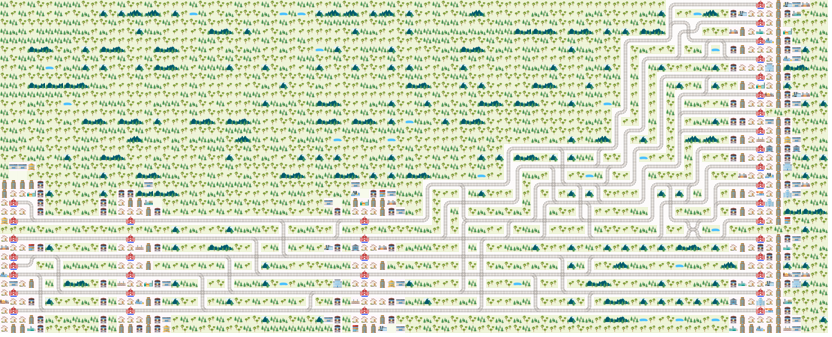

In [8]:
from flatland.utils.rendertools import RenderTool

env = make_env(SCENARIO, CONDITION, seed=SEED)

print(f"scenario: {SCENARIO} | condition: {CONDITION}")
print(f"grid: {env.width} x {env.height} (w x h)")
print("agents:", env.get_num_agents(), "| max episode steps:", env._max_episode_steps)
print("obs space:", env.obs_builder.get_observation_space(0))

# Preview the prebuilt level and fleet.
_renderer = RenderTool(
    env, gl="PILSVG", screen_width=1000,
    screen_height=int(1000 * env.height / env.width),
)
show_image(
    _renderer.render_env(show=False, show_agents=False, show_observations=False, return_image=True)
)
_renderer.close_window()


## 4. RL wrappers (PettingZoo to SuperSuit)

One sub-env per agent (shared policy), replicated across workers, with optional
reward normalisation. These are environment utilities; the algorithms in §5 train
against the `VecEnv` this returns.


In [9]:
import supersuit as ss
from stable_baselines3.common.vec_env import VecNormalize


def build_vec_env(scenario=SCENARIO, condition=CONDITION, n_envs=2, n_cpus=0,
                  seed=SEED, max_depth=MAX_DEPTH, predictor_depth=PREDICTOR_DEPTH,
                  norm_reward=True, gamma=0.99, clip_reward=10.0,
                  force_stop=FORCE_STOP, dwell_extra=0):
    """PettingZoo parallel env -> SuperSuit VecEnv (optionally VecNormalize'd)."""
    parallel = make_parallel_env(
        scenario=scenario, condition=condition, seed=seed,
        max_depth=max_depth,
        force_stop=force_stop, dwell_extra=dwell_extra,
    )
    vec = ss.pettingzoo_env_to_vec_env_v1(parallel)
    vec = ss.concat_vec_envs_v1(vec, n_envs, num_cpus=n_cpus, base_class="stable_baselines3")
    # SB3 calls env.seed() during set_random_seed; SuperSuit's ConcatVecEnv has no
    # seed(), so provide a no-op (Flatland reseeds from its own RNG on reset).
    vec.seed = lambda seed=None: [None] * vec.num_envs
    if norm_reward:
        vec = VecNormalize(vec, norm_obs=False, norm_reward=True,
                           clip_reward=clip_reward, gamma=gamma)
    return vec


## 5. Algorithms (TODO)

Implement each algorithm with a **shared policy across agents** (independent
learning / parameter sharing) over the flattened tree observation from
`build_vec_env()`. Suggested order: PPO (primary), then A2C and DQN.

Common requirements:
- MLP over the flattened tree observation (1020-d tree + 6 next-stop features); discrete action head (5 actions).
- Use `build_vec_env()` for rollouts and `evaluate(policy_fn)` (§6) for metrics.
- Log `step, normalized_score, completion_rate` to `results/<algo>/<run>/eval.csv`.
- Reuse the real-timetable delay metrics to report lateness vs the schedule.

Each stub below only *defines* the entry point (so the notebook still runs);
fill in the implementation.

### 5.1 PPO (primary)

In [10]:
# TODO(PPO): implement the primary algorithm.
#   - shared MLP actor-critic (policy + value heads)
#   - rollout buffer + GAE(lambda) advantage estimation
#   - clipped surrogate policy loss, value loss, entropy bonus
#   - advantage normalisation, multiple epochs/minibatches, gradient clipping
#   - train on build_vec_env(); return the trained policy
def train_ppo(train_env, eval_env, total_timesteps=15_000_000, **kwargs):
    """TODO: implement PPO and return the trained policy."""
    raise NotImplementedError("TODO: implement PPO")

### 5.2 A2C

In [11]:
# TODO(A2C): implement the advantage actor-critic baseline.
#   - shared MLP actor-critic; synchronous updates on n-step returns (or GAE)
#   - value loss + entropy bonus; gradient clipping
def train_a2c(train_env, eval_env, total_timesteps=15_000_000, **kwargs):
    """TODO: implement A2C and return the trained policy."""
    raise NotImplementedError("TODO: implement A2C")

### 5.3 DQN

In [12]:
# TODO(DQN): implement the off-policy value-based baseline.
#   - shared Q-network with a replay buffer and a target network
#   - epsilon-greedy exploration; Bellman target updates (discrete actions)
def train_dqn(train_env, eval_env, total_timesteps=15_000_000, **kwargs):
    """TODO: implement DQN and return the trained policy."""
    raise NotImplementedError("TODO: implement DQN")

## 6. Evaluation

`evaluate(policy_fn=None)` is framework-agnostic: `policy_fn` maps a single
observation (numpy array) to a discrete action, or pass `None` for the
distance-map greedy baseline. It reports the normalized score, completion rate,
**timetable delay** (mean and total), on-time fraction, cumulative return and a
collision/deadlock proxy.

`evaluate_seeds(policy_fn=None, ...)` runs `evaluate` once per seed in `SEEDS`
(§1) and returns the per-seed rows plus a mean/std summary, for reporting
`mean +/- std` across seeds.


In [13]:
def evaluate(policy_fn=None, scenario=SCENARIO, condition=CONDITION,
             n_episodes=5, seed=SEED + 2000,
             max_depth=MAX_DEPTH, predictor_depth=PREDICTOR_DEPTH,
             force_stop=FORCE_STOP, dwell_extra=0):
    """Deterministic evaluation of any policy (or the greedy baseline).

    ``policy_fn(obs: np.ndarray) -> int`` returns an action index (0-4); pass
    ``None`` to evaluate the distance-map greedy baseline. Reports score,
    completion, delay (mean + total), on-time, cumulative return and a
    collision/deadlock proxy.
    """
    env = make_parallel_env(
        scenario=scenario, condition=condition, seed=seed,
        max_depth=max_depth, predictor_depth=predictor_depth,
        force_stop=force_stop, dwell_extra=dwell_extra,
    )
    raw = env._wrap
    handles = list(env.possible_agents)
    max_steps = raw._max_episode_steps

    scores, completions = [], []
    mean_delays, total_delays, on_times = [], [], []
    returns, collisions, stops_served = [], [], []
    for ep in range(n_episodes):
        obs, _ = env.reset(seed=seed * 1000 + ep)
        cum = {h: 0.0 for h in handles}
        done = {h: False for h in handles}
        reached = {h: False for h in handles}
        done_step = {}
        # Intermediate waypoint cells per agent, and which ones got a STOPPED step.
        inter_cells = {
            h: {tuple(int(x) for x in wp.position)
                for grp in raw.agents[h].waypoints[1:-1] for wp in grp}
            for h in handles
        }
        served = {h: set() for h in handles}
        step = 0
        for step in range(1, max_steps + 1):
            if policy_fn is None:
                greedy = greedy_actions(raw)
                actions = {h: (0 if done[h] else int(greedy.get(h, 0))) for h in handles}
            else:
                actions = {h: (0 if done[h] else int(policy_fn(obs[h]))) for h in handles}
            obs, rewards, terms, _, infos = env.step(actions)
            for h, r in rewards.items():
                if r is not None:
                    cum[h] += float(r)
            for h in handles:
                if terms.get(h):
                    done[h] = True
                if infos[h].get("state") == TrainState.DONE:
                    reached[h] = True
                    done_step.setdefault(h, step)
                if infos[h].get("state") == TrainState.STOPPED:
                    cfg = raw.agents[h].current_configuration
                    if cfg is not None and cfg[0] is not None:
                        pos = tuple(int(x) for x in cfg[0])
                        if pos in inter_cells[h]:
                            served[h].add(pos)
            if all(done.values()):
                break

        rewards_arr = np.array([cum[h] for h in handles])
        # normalize() returns [0, 1]; shift to (-1, 0] to match the training curve.
        scores.append(float(raw.rewards.normalize(
            *rewards_arr, num_agents=len(handles), max_episode_steps=max_steps)) - 1.0)
        returns.append(float(np.mean(rewards_arr)))
        completions.append(sum(reached.values()) / len(handles))
        scheduled = [raw.agents[h].waypoints_latest_arrival[-1] for h in handles]
        delays = [done_step[h] - scheduled[h]
                  for h in handles if h in done_step and scheduled[h] is not None]
        if delays:
            mean_delays.append(float(np.mean(delays)))
            total_delays.append(float(np.sum(delays)))
            on_times.append(float(np.mean([d <= 0 for d in delays])))
        # Collision/deadlock proxy: the episode ended before the horizon with
        # agents still short of their target.
        collisions.append(
            sum(1 for h in handles if not reached[h]) if step < max_steps else 0
        )
        total_inter = sum(len(inter_cells[h]) for h in handles)
        n_served = sum(len(served[h]) for h in handles)
        stops_served.append(n_served / total_inter if total_inter else float("nan"))

    env.close()
    return {
        "score": float(np.mean(scores)),
        "completion": float(np.mean(completions)),
        "mean_delay_steps": float(np.mean(mean_delays)) if mean_delays else float("nan"),
        "total_delay_steps": float(np.mean(total_delays)) if total_delays else float("nan"),
        "on_time": float(np.mean(on_times)) if on_times else float("nan"),
        "mean_return": float(np.mean(returns)),
        "collisions": float(np.mean(collisions)),
        "stops_served": float(np.nanmean(stops_served)),
    }


def evaluate_seeds(policy_fn=None, scenario=SCENARIO, condition=CONDITION,
                   seeds=SEEDS, n_episodes=5,
                   max_depth=MAX_DEPTH, predictor_depth=PREDICTOR_DEPTH,
                   force_stop=FORCE_STOP, dwell_extra=0):
    """Run evaluate() once per seed; return per-seed rows and a mean/std summary."""
    rows = []
    for seed in seeds:
        result = evaluate(policy_fn, scenario=scenario, condition=condition,
                          n_episodes=n_episodes, seed=seed,
                          max_depth=max_depth, predictor_depth=predictor_depth,
                          force_stop=force_stop, dwell_extra=dwell_extra)
        rows.append({"seed": seed, **result})
    per_seed = pd.DataFrame(rows).set_index("seed")
    summary = pd.DataFrame({
        "mean": per_seed.mean(),
        "std": per_seed.std(ddof=0),
    })
    return per_seed, summary


### 6.1 Greedy baseline: normal vs delayed across seeds

Evaluate the distance-map greedy policy (which serves intermediate stops: it
stops at each intermediate waypoint and leaves at its scheduled earliest
departure) under both operating conditions, once per seed in `SEEDS` (§1,
default `[0, 1, 2]`). The cell shows the per-seed rows and the mean +/- std
summary. Delay is `actual arrival step - scheduled arrival step` (positive =
late); `on_time` is the fraction arriving no later than scheduled;
`stops_served` is the fraction of intermediate stops with a `STOPPED` step
(Flatland only counts a stop as served if the train actually stops);
`collisions` is the number of agents left short of their target when an episode
ends early (collision / deadlock proxy).


In [14]:
per_seed_frames, summary_rows = [], []
for condition in ["normal", "delayed"]:
    per_seed, summary = evaluate_seeds(None, condition=condition, n_episodes=3)
    per_seed_frames.append(
        per_seed.assign(condition=condition).reset_index().set_index(["condition", "seed"])
    )
    summary_rows.append({
        "condition": condition,
        **{metric: f"{summary.loc[metric, 'mean']:.3f} ± {summary.loc[metric, 'std']:.3f}"
           for metric in summary.index},
    })

per_seed_all = pd.concat(per_seed_frames)
summary_all = pd.DataFrame(summary_rows).set_index("condition")

try:
    from IPython.display import display
except Exception:
    display = print

print(f"Per-seed results (SEEDS={SEEDS}, n_episodes=3):")
display(per_seed_all.round(3))
print("Mean ± std across seeds:")
display(summary_all)


Per-seed results (SEEDS=[0, 1, 2], n_episodes=3):


score  completion  mean_delay_steps  total_delay_steps  \
condition seed                                                           
normal    0    -0.230       0.662            13.653            669.000   
          1    -0.230       0.662            13.653            669.000   
          2    -0.230       0.662            13.653            669.000   
delayed   0    -0.282       0.599            34.865           1553.000   
          1    -0.284       0.599            37.637           1683.333   
          2    -0.249       0.640            35.942           1700.333   

                on_time  mean_return  collisions  stops_served  
condition seed                                                  
normal    0         0.0     -235.986         0.0         0.154  
          1         0.0     -235.986         0.0         0.154  
          2         0.0     -235.986         0.0         0.154  
delayed   0         0.0     -289.551         0.0         0.143  
          1         0.0     -291.757         0.0         0.143  
          2         0.0     -255.595         0.0         0.149

Mean ± std across seeds:


,score,completion,mean_delay_steps,total_delay_steps,on_time,mean_return,collisions,stops_served
condition,,,,,,,,
normal,-0.230 ± 0.000,0.662 ± 0.000,13.653 ± 0.000,669.000 ± 0.000,0.000 ± 0.000,-235.986 ± 0.000,0.000 ± 0.000,0.154 ± 0.000
delayed,-0.272 ± 0.016,0.613 ± 0.019,36.148 ± 1.141,1645.556 ± 65.814,0.000 ± 0.000,-278.968 ± 16.552,0.000 ± 0.000,0.145 ± 0.003


## 7. Scenario comparison

The greedy baseline is rendered for scenario 1 under both operating conditions
(`scenario1_greedy_normal.gif`, `scenario1_greedy_delayed.gif`), and the metric
panel overlays each algorithm's training curves against the normal baseline.
Scenario 2 (Granville-Harris Park) is pending (§9), so the side-by-side corridor
comparison activates once its `SCENARIOS` entry is filled in.


### 7.1 Scenario 1 greedy baseline rollout (normal and delayed)


scenario 1 greedy [normal]: {'gif': '/Users/weihuazhang/Documents/James/RL-Assessment-3/docs/comparison/scenario1_greedy_normal.gif', 'frames': 1027, 'steps': 1026, 'score': -0.23000632211158545, 'completion': 0.6621621621621622, 'mean_delay_steps': 13.653061224489797, 'on_time': 0.0}


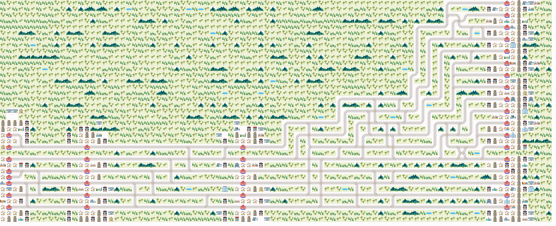

scenario 1 greedy [delayed]: {'gif': '/Users/weihuazhang/Documents/James/RL-Assessment-3/docs/comparison/scenario1_greedy_delayed.gif', 'frames': 1027, 'steps': 1026, 'score': -0.2918655497602869, 'completion': 0.5675675675675675, 'mean_delay_steps': 17.476190476190474, 'on_time': 0.0}


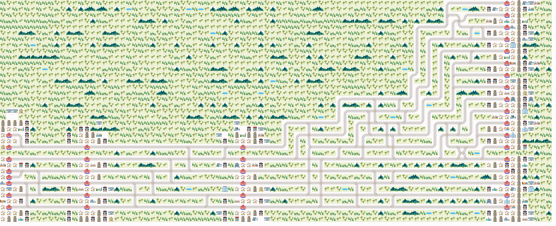

In [15]:
for condition in ["normal", "delayed"]:
    env_c = env if condition == CONDITION else make_env(SCENARIO, condition, seed=SEED)
    stats = rollout_gif(
        env_c, DOCS / f"scenario1_greedy_{condition}.gif",
        fps=8, screen_width=700, seed=SEED,
    )
    GREEDY_BASELINE[condition] = stats
    print(f"scenario 1 greedy [{condition}]:", stats)
    try:
        from IPython.display import Image as IPyImage, display
        display(IPyImage(filename=stats["gif"]))
    except Exception:
        print("saved:", stats["gif"])


### 7.2 Metric comparison

One mean line per algorithm (averaged over its runs); the dashed grey line is
the scenario-1 greedy baseline. Any `results/<algo>/<run>/eval.csv` runs are
picked up automatically.

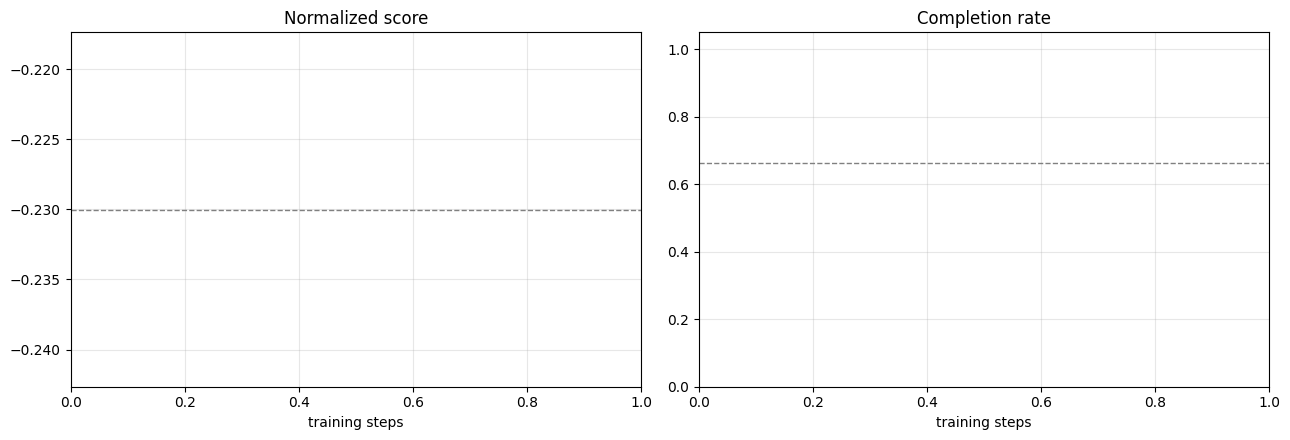

0 algorithm(s) with eval curves


In [16]:
RESULTS_ROOT = ROOT / "results"
metrics = [("normalized_score", "Normalized score"), ("completion_rate", "Completion rate")]
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
found = 0
for algo_dir in sorted(p for p in RESULTS_ROOT.glob("*") if p.is_dir()):
    csvs = sorted(algo_dir.glob("*/eval.csv"))
    if not csvs:
        continue
    found += 1
    runs = [pd.read_csv(c).dropna(subset=["step"]).sort_values("step") for c in csvs]
    for ax, (key, title) in zip(axes, metrics):
        grid = np.linspace(0, max(r["step"].max() for r in runs), 200)
        curves = [np.interp(grid, r["step"], r[key]) for r in runs if key in r]
        if curves:
            ax.plot(grid, np.mean(curves, axis=0), label=algo_dir.name)
base = GREEDY_BASELINE.get("normal")
if base:
    axes[0].axhline(base["score"], ls="--", lw=1, color="grey")
    axes[1].axhline(base["completion"], ls="--", lw=1, color="grey")
for ax, (key, title) in zip(axes, metrics):
    ax.set_title(title)
    ax.set_xlabel("training steps")
    ax.grid(alpha=0.3)
axes[1].set_ylim(0, 1.05)
if found:
    axes[0].legend()
plt.tight_layout()
plt.show()
print(f"{found} algorithm(s) with eval curves")

## 8. Save / load (TODO)

In [17]:
# TODO: persist your trained policies and any observation/reward normalisation
# statistics, then reload them for evaluation, e.g.
#   torch.save(policy.state_dict(), run_dir / "policy.pt")
#   train_env.save(run_dir / "vecnormalize.pkl")   # if using SB3's VecNormalize
def load_policy(run_dir):
    """TODO: load a saved policy for evaluation."""
    raise NotImplementedError("TODO: implement load_policy")

## 9. Scenario 2: Granville-Harris Park (TODO)

The Part-B plan commits to a second scenario on the Main Western line: a flat
junction (no flyover) where the suburban line and the Old South service from
Merrylands converge and diverge. It mirrors scenario 1: add the level to
`data/levels/`, the schedule to `data/schedules/`, register it in `SCENARIOS`
(§2.3), and remove the `make_scenario2_env` stub, reusing the same observation,
wrappers, evaluation and plotting.


In [18]:
def make_scenario2_env(seed: int | None = None, **kwargs):
    """TODO(scenario 2): Granville-Harris Park flat junction (Main Western).

    Add the second level and schedule under ``data/``, extend the build script
    to assemble its env, and replace the ``"granville-harris-park"`` entry in
    :data:`SCENARIOS`; this thin wrapper (plus ``make_env``) will then drive it.
    """
    raise NotImplementedError("TODO: implement scenario 2 (Granville-Harris Park)")


## 10. Notes and next steps

- **Scenario data**: the level and schedule live under `data/` and the assembled
  env is built by `scripts/build_scenario1_env.py`. Rebuild it if the rail grid or
  schedule changes, then rerun the notebook from the repo root.
- **Algorithms**: implement PPO / A2C / DQN (see §5 stubs); shared policy across
  agents, logging to `results/<algo>/<run>/eval.csv`.
- **Scenario 2**: add its level and schedule under `data/`, extend
  `scripts/build_scenario1_env.py` (or a sibling), register it in `SCENARIOS`
  (§2.3), then remove the `make_scenario2_env` stub (§9) and extend §7 to a
  side-by-side comparison.
- **Disruptions**: `CONDITION="delayed"` injects Poisson malfunctions (1/540)
  via the env's effects generator; §6.1 compares the greedy baseline under
  `normal` vs `delayed`.
- **Force-stop reflex**: `FORCE_STOP` (§1, default `True`) env-enforces scheduled
  stops: a train at a stop cell is forced to `STOP_MOVING` and held for its
  scheduled dwell (§2.4, `force_stop_actions` / `install_force_stop`). Set
  `FORCE_STOP = False` (or pass `force_stop=False` to the factories / `evaluate`)
  to make the policy learn to stop on its own.
- **Metrics**: `evaluate()` reports score, completion, mean/total delay, on-time,
  cumulative return and a collision/deadlock proxy; reroutings remain to be added
  for the final report.
- **Lane changes**: Flatland has no routing flexibility for intermediate stops, so
  each stop is a single waypoint; a train changes track only via `MOVE_LEFT` /
  `MOVE_RIGHT` at switch cells. Add a junction scenario (scenario 2) or a
  preferred-platform reward to exercise it.
- **Scale up**: train on AWS SageMaker (GPU) with PyTorch via a scripted job;
  export policies and demonstrate locally with the Flatland renderer.
- **Reproducibility**: `SEEDS` (§1) drives `evaluate_seeds`, which reports
  mean +/- std across seeds; fix `SEED` for a single deterministic run.
